In [1]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import yaml

from data.patching import build_patch_registry, assign_hits_to_patches_barrel

In [2]:
detector_type = "HCAL"
data_dir = pickle.load(open("/pscratch/sd/r/rmastand/data_dir.pkl", "rb"))


with open("../configs/detector_patching_params.yaml", "r") as ifile:
    detector_patching_params = yaml.safe_load(ifile)[detector_type]

    
print(detector_patching_params)

{'cell_size': 30.0, 'layer_width': 51.0, 'endcap_configs': {'n_bins_x': 101, 'x_start_midpoint': 362.5, 'x_stop_midpoint': 3362.5, 'n_bins_y': 45, 'y_start_midpoint': -660.0, 'y_stop_midpoint': 660.0, 'n_bins_z': 36, 'z_start_midpoint': 3647.5, 'z_stop_midpoint': 5432.5}, 'barrel_configs': {'n_bins_x': 36, 'x_start_midpoint': 1647.5, 'x_stop_midpoint': 3432.5, 'n_bins_y': 45, 'y_start_midpoint': -660.0, 'y_stop_midpoint': 660.0, 'n_bins_z': 231, 'z_start_midpoint': -3450.0, 'z_stop_midpoint': 3450.0, 'cells_per_wedge': {0: 23, 1: 23, 2: 23, 3: 25, 4: 25, 5: 25, 6: 27, 7: 27, 8: 27, 9: 29, 10: 29, 11: 29, 12: 31, 13: 31, 14: 31, 15: 33, 16: 33, 17: 33, 18: 35, 19: 35, 20: 35, 21: 37, 22: 37, 23: 37, 24: 39, 25: 39, 26: 39, 27: 41, 28: 41, 29: 41, 30: 43, 31: 43, 32: 43, 33: 45, 34: 45, 35: 45}, 'cells_per_patch_z': 11, 'cells_per_patch_phi': {0: 8, 1: 8, 2: 8, 3: 10, 4: 10, 5: 10, 6: 12, 7: 12, 8: 12, 9: 16, 10: 16, 11: 16, 12: 16, 13: 16, 14: 16, 15: 16, 16: 16, 17: 16, 18: 16, 19: 16,

In [3]:
# for key in data_dir.keys():
#     plt.figure()
#     plt.hist(data_dir[key], bins = 100, histtype = "step", density = True)
#     plt.xlabel(key)
#     plt.ylabel("density")
#     plt.show()

In [4]:
ECAL_layers = [9, 10, 11]
labels = ["ECAL endcap", "ECAL barrel", "ECAL endcap"]
HCAL_layers = [12, 13, 14]
labels = ["HCAL endcap", "HCAL barrel", "HCAL endcap"]


"""
for i, detector_idx in enumerate(ECAL_layers):
    detector_mask = data_dir["detector"] == detector_idx

    plt.figure(figsize = (16, 6))
    plt.scatter(
        data_dir["z"][detector_mask], 
        data_dir["r"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.0001,
        label = labels[i]
        )
   # plt.legend(loc = (1, 0))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(labels[i])
    plt.xlabel("z [mm]")
    plt.ylabel("r [mm]")
    plt.show()


    plt.figure(figsize = (16, 6))
    
    plt.scatter(
        data_dir["x"][detector_mask], 
        data_dir["y"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.000100,
        label = labels[i]
        )
   #plt.legend(loc = (1, 0))
    plt.title(labels[i])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.show()

"""


'\nfor i, detector_idx in enumerate(ECAL_layers):\n    detector_mask = data_dir["detector"] == detector_idx\n\n    plt.figure(figsize = (16, 6))\n    plt.scatter(\n        data_dir["z"][detector_mask], \n        data_dir["r"][detector_mask], \n        color = f"C{detector_idx}", \n        s = 0.0001,\n        label = labels[i]\n        )\n   # plt.legend(loc = (1, 0))\n    plt.gca().set_aspect(\'equal\', adjustable=\'box\')\n    plt.title(labels[i])\n    plt.xlabel("z [mm]")\n    plt.ylabel("r [mm]")\n    plt.show()\n\n\n    plt.figure(figsize = (16, 6))\n    \n    plt.scatter(\n        data_dir["x"][detector_mask], \n        data_dir["y"][detector_mask], \n        color = f"C{detector_idx}", \n        s = 0.000100,\n        label = labels[i]\n        )\n   #plt.legend(loc = (1, 0))\n    plt.title(labels[i])\n    plt.gca().set_aspect(\'equal\', adjustable=\'box\')\n    plt.xlabel("x [mm]")\n    plt.ylabel("y [mm]")\n    plt.show()\n\n'

In [5]:

"""
for i, detector_idx in enumerate(HCAL_layers):
    detector_mask = data_dir["detector"] == detector_idx

    plt.figure(figsize = (16, 6))
    plt.scatter(
        data_dir["z"][detector_mask], 
        data_dir["r"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.0001,
        label = labels[i]
        )
   # plt.legend(loc = (1, 0))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(labels[i])
    plt.xlabel("z [mm]")
    plt.ylabel("r [mm]")
    plt.show()


    plt.figure(figsize = (16, 6))
    
    plt.scatter(
        data_dir["x"][detector_mask], 
        data_dir["y"][detector_mask], 
        color = f"C{detector_idx}", 
        s = 0.000100,
        label = labels[i]
        )
   #plt.legend(loc = (1, 0))
    plt.title(labels[i])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.show()
"""



'\nfor i, detector_idx in enumerate(HCAL_layers):\n    detector_mask = data_dir["detector"] == detector_idx\n\n    plt.figure(figsize = (16, 6))\n    plt.scatter(\n        data_dir["z"][detector_mask], \n        data_dir["r"][detector_mask], \n        color = f"C{detector_idx}", \n        s = 0.0001,\n        label = labels[i]\n        )\n   # plt.legend(loc = (1, 0))\n    plt.gca().set_aspect(\'equal\', adjustable=\'box\')\n    plt.title(labels[i])\n    plt.xlabel("z [mm]")\n    plt.ylabel("r [mm]")\n    plt.show()\n\n\n    plt.figure(figsize = (16, 6))\n    \n    plt.scatter(\n        data_dir["x"][detector_mask], \n        data_dir["y"][detector_mask], \n        color = f"C{detector_idx}", \n        s = 0.000100,\n        label = labels[i]\n        )\n   #plt.legend(loc = (1, 0))\n    plt.title(labels[i])\n    plt.gca().set_aspect(\'equal\', adjustable=\'box\')\n    plt.xlabel("x [mm]")\n    plt.ylabel("y [mm]")\n    plt.show()\n'

In [6]:

# import numpy as np


# def assign_hits_to_cells(x, y, z, detector_index):
#     """
#     Assign hits to HCAL cells in endcap.
#     Sector 0 is fixed; all other sectors rotated to align with sector 0.
#     """

#     n_sectors = 16
#     half_wedge = np.pi / n_sectors


#     x = np.asarray(x)
#     y = np.asarray(y)
#     z = np.asarray(z)


#     # HCAL
#     if detector_index in [12, 13, 14]:
#         detector_id = "HCAL"
#     elif detector_index in [9, 10, 11]:
#         detector_id = "ECAL"
        
#     cell_size = detector_params[detector_id]["cell_size"] 
#     layer_width = detector_params[detector_id]["layer_width"] 
       

#     # endcaps
#     if detector_index in [9, 11, 12, 14]:
#         n_bins_x = detector_params[detector_id]["endcap_configs"]["n_bins_x"]
#         n_bins_y = detector_params[detector_id]["endcap_configs"]["n_bins_y"]
#         n_bins_z = detector_params[detector_id]["endcap_configs"]["n_bins_z"]
        
#         x_start, x_stop = detector_params[detector_id]["endcap_configs"]["x_start_midpoint"] - cell_size/2, detector_params[detector_id]["endcap_configs"]["x_stop_midpoint"] + cell_size/2
#         y_start, y_stop = detector_params[detector_id]["endcap_configs"]["y_start_midpoint"] - cell_size/2, detector_params[detector_id]["endcap_configs"]["y_stop_midpoint"] + cell_size/2
#         z_start, z_stop = detector_params[detector_id]["endcap_configs"]["z_start_midpoint"] - layer_width/2, detector_params[detector_id]["endcap_configs"]["z_stop_midpoint"] + layer_width/2
        
#         if detector_index in [9, 12]:
#             z_start, z_stop = -z_stop, -z_start
    
#     # barrel
#     elif detector_index in [10, 13]:
#         n_bins_x = detector_params[detector_id]["barrel_configs"]["n_bins_x"]
#         n_bins_y = detector_params[detector_id]["barrel_configs"]["n_bins_y"]
#         n_bins_z = detector_params[detector_id]["barrel_configs"]["n_bins_z"]
        
#         x_start, x_stop = detector_params[detector_id]["barrel_configs"]["x_start_midpoint"] - layer_width/2, detector_params[detector_id]["barrel_configs"]["x_stop_midpoint"] + layer_width/2
#         y_start, y_stop = detector_params[detector_id]["barrel_configs"]["y_start_midpoint"] - cell_size/2, detector_params[detector_id]["barrel_configs"]["y_stop_midpoint"] + cell_size/2
#         z_start, z_stop = detector_params[detector_id]["barrel_configs"]["z_start_midpoint"] - cell_size/2, detector_params[detector_id]["barrel_configs"]["z_stop_midpoint"] + cell_size/2




#     x_edges = np.linspace(x_start, x_stop , n_bins_x + 1)
#     y_edges = np.linspace(y_start, y_stop, n_bins_y + 1)
#     z_edges = np.linspace(z_start, z_stop , n_bins_z + 1)



#     # print(x_edges[1:]-x_edges[:-1])
#     # print(len(x_edges)-1)
#     # print()
#     # print(y_edges[1:]-y_edges[:-1])
#     # print(len(y_edges)-1)
#     # print()
#     # print(z_edges[1:]-z_edges[:-1])
#     # print(len(z_edges)-1)
#     # print()


#     # --- Step 1: compute wedge ---
#     angles = np.arctan2(y, x)
#     angles[angles < 0] += 2*np.pi
#     angles = (angles + half_wedge) % (2*np.pi)
#     sector_idx = (angles / (2*np.pi) * n_sectors).astype(int)

#     # --- Step 2: compute rotation angles to align with sector 0 ---
#     delta_theta = 2*np.pi / n_sectors
#     theta_center = (sector_idx + 0.5) * delta_theta
#     theta_center_0 = (0 + 0.5) * delta_theta  # sector 0 center angle

#     theta_rot = - (theta_center - theta_center_0)  # rotate other sectors to align with sector 0

#     # --- Step 3: rotate hits into sector 0-aligned frame ---
#     x_local = x * np.cos(theta_rot) - y * np.sin(theta_rot)
#     y_local = x * np.sin(theta_rot) + y * np.cos(theta_rot)


#     # print("x")
#     # tmp = np.unique(np.round(x_local, 2))
#     # #print(tmp)
#     # #print(tmp[1:] - tmp[:-1])
#     # print(np.min(tmp), np.max(tmp), (np.max(tmp) - np.min(tmp))/cell_size)


#     # print("y")
#     # tmp = np.unique(np.round(y_local, 2))
#     # #print(tmp)
#     # #print(tmp[1:] - tmp[:-1])
#     # print(np.min(tmp), np.max(tmp), (np.max(tmp) - np.min(tmp))/cell_size)

#     # print("z")
#     # tmp = np.unique(np.round(z, 2))
#     # #print(tmp)
#     # #print(tmp[1:] - tmp[:-1])
#     # print(np.min(tmp), np.max(tmp), (np.max(tmp) - np.min(tmp))/layer_width)

    
#     # --- Step 5: assign hits to cell indices ---
#     x_cell_idx = np.digitize(x_local, x_edges) - 1  # subtract 1 to make 0-based
#     y_cell_idx = np.digitize(y_local, y_edges) - 1
#     z_cell_idx = np.digitize(z, z_edges) - 1

#     # Mask for unassigned hits in any dimension
#     nx = len(x_edges) - 1
#     ny = len(y_edges) - 1
#     nz = len(z_edges) - 1

#     unassigned_mask = (
#         (x_cell_idx < 0) | (x_cell_idx >= nx) |
#         (y_cell_idx < 0) | (y_cell_idx >= ny) |
#         (z_cell_idx < 0) | (z_cell_idx >= nz)
#     )

#     # Extract coordinates of unassigned hits
#     x_unassigned = x_local[unassigned_mask]
#     y_unassigned = y_local[unassigned_mask]
#     z_unassigned = z[unassigned_mask]

#     # Print results
#     #print(f"Number of unassigned hits: {len(x_unassigned)}")
#     if len(x_unassigned) > 0:
#         print(f"ERROR: {len(x_unassigned)} hits!!!")
#         #for xi, yi, zi in zip(x_unassigned, y_unassigned, z_unassigned):
#          #   print(f"x={xi}, y={yi}, z={zi}")
 

#     # counts_x = np.bincount(x_cell_idx, minlength=nx)
#     # counts_y = np.bincount(y_cell_idx, minlength=ny)
#     # counts_z = np.bincount(z_cell_idx, minlength=nz)

#     # empty_x = np.where(counts_x == 0)[0]
#     # empty_y = np.where(counts_y == 0)[0]
#     # empty_z = np.where(counts_z == 0)[0]

#     # print("x cell indices with no hits:", empty_x)
#     # print("y cell indices with no hits:", empty_y)
#     # print("z cell indices with no hits:", empty_z)

#     # # get the actual cell edge values for the bins with zero hits
#     # x_edges_no_hits = x_edges[empty_x]
#     # y_edges_no_hits = y_edges[empty_y]
#     # z_edges_no_hits = z_edges[empty_z]
#     # print("x cell edges with no hits:", x_edges_no_hits)
#     # print("y cell edges with no hits:", y_edges_no_hits)
#     # print("z cell edges with no hits:", z_edges_no_hits)
    
#     return sector_idx, x_cell_idx, y_cell_idx, z_cell_idx, x_local, y_local

# dd = 14

# # Example: 36 cells for detector hits
# x = data_dir["x"][data_dir["detector"] == dd]
# y = data_dir["y"][data_dir["detector"] == dd]
# z = data_dir["z"][data_dir["detector"] == dd]
# energy = data_dir["total_energy"][data_dir["detector"] == dd]

# sectors, x_cell_idx, y_cell_idx, z_cell_idx,  x_local, y_local  = assign_hits_to_cells(x,y,z, dd)


In [7]:


# unique_x_hits = set(x_cell_idx)
# for i in range(36):
#     in_x_layer = x_cell_idx==i
#     print(i, np.min(y_cell_idx[in_x_layer]), np.max(y_cell_idx[in_x_layer]), len(set(y_cell_idx[in_x_layer])))


# Determine patching in phi. This should be hardcoded into the yaml file

In [8]:
def get_cells_per_patch_phi(
    cells_per_wedge,
    target_phi,
    verbose = True
):

    cells_per_patch_layer = {}

    
    for i in range(len(cells_per_wedge.keys())):

        trial_num_cells_per_patch = []

        # calculate the total number of cells in the ring
        total_cells_layer = cells_per_wedge[i]*16

        # get a good starting guess. Don't decrease binning from previous later
        closest_match = target_phi * total_cells_layer / (2*np.pi)
        try:
            start_num_cells = np.max([int(closest_match) - 4, cells_per_patch_layer[i-1]])
        except KeyError:
            start_num_cells = int(closest_match) - 4
        
        for trial_num_cell in range(start_num_cells, start_num_cells + 100, 1):
            num_patches = total_cells_layer / trial_num_cell
            
            if (int(num_patches) == num_patches):
                trial_num_cells_per_patch.append(trial_num_cell)
                
        trial_phis = 2 * np.pi * np.array(trial_num_cells_per_patch) / total_cells_layer
        
        best_num_cells = trial_num_cells_per_patch[np.argmin(np.abs(trial_phis - target_phi))]


        if verbose:
            print(f"Layer {i}: cells of size {best_num_cells} with deltaphi {2 * np.pi * best_num_cells / total_cells_layer}")
            
        cells_per_patch_layer[i] = best_num_cells

    return cells_per_patch_layer
            
    

In [9]:
target_phi = 0.2

cells_per_patch_phi = get_cells_per_patch_phi(
    detector_patching_params["barrel_configs"]["cells_per_wedge"],
    target_phi
)



Layer 0: cells of size 8 with deltaphi 0.13659098493868665
Layer 1: cells of size 8 with deltaphi 0.13659098493868665
Layer 2: cells of size 8 with deltaphi 0.13659098493868665
Layer 3: cells of size 10 with deltaphi 0.15707963267948966
Layer 4: cells of size 10 with deltaphi 0.15707963267948966
Layer 5: cells of size 10 with deltaphi 0.15707963267948966
Layer 6: cells of size 12 with deltaphi 0.17453292519943295
Layer 7: cells of size 12 with deltaphi 0.17453292519943295
Layer 8: cells of size 12 with deltaphi 0.17453292519943295
Layer 9: cells of size 16 with deltaphi 0.21666156231653746
Layer 10: cells of size 16 with deltaphi 0.21666156231653746
Layer 11: cells of size 16 with deltaphi 0.21666156231653746
Layer 12: cells of size 16 with deltaphi 0.2026833970057931
Layer 13: cells of size 16 with deltaphi 0.2026833970057931
Layer 14: cells of size 16 with deltaphi 0.2026833970057931
Layer 15: cells of size 16 with deltaphi 0.19039955476301776
Layer 16: cells of size 16 with deltaphi

In [10]:
for i in cells_per_patch_phi.keys():
    print(f"{i}: {cells_per_patch_phi[i]}")




0: 8
1: 8
2: 8
3: 10
4: 10
5: 10
6: 12
7: 12
8: 12
9: 16
10: 16
11: 16
12: 16
13: 16
14: 16
15: 16
16: 16
17: 16
18: 16
19: 16
20: 16
21: 16
22: 16
23: 16
24: 16
25: 16
26: 16
27: 16
28: 16
29: 16
30: 43
31: 43
32: 43
33: 45
34: 45
35: 45


# More patching

In [11]:

num_wedges = 16


def do_detector_patching(
    detector_patching_params,
    R,
):

    cells_per_wedge = detector_patching_params["barrel_configs"]["cells_per_wedge"]
    cells_per_patch_phi = detector_patching_params["barrel_configs"]["cells_per_patch_phi"]
    cells_per_patch_z = detector_patching_params["barrel_configs"]["cells_per_patch_z"]
    cell_size = detector_patching_params["cell_size"]
    layer_width = detector_patching_params["layer_width"]
    num_cells_z = detector_patching_params["barrel_configs"]["n_bins_z"]
    r_start = detector_patching_params["barrel_configs"]["x_start_midpoint"] - layer_width / 2
    r_stop = detector_patching_params["barrel_configs"]["x_stop_midpoint"] + layer_width / 2
    z_start = detector_patching_params["barrel_configs"]["z_start_midpoint"] - cell_size / 2
    z_stop = detector_patching_params["barrel_configs"]["z_stop_midpoint"] + cell_size / 2
    offsets = detector_patching_params["barrel_configs"]["offsets"]
    groups = detector_patching_params["barrel_configs"]["groups"]


    plt.figure(figsize=(30, 30))
    
    patches_phi_per_ring = {}
    delta_phi_per_ring = {}
    delta_etas_per_ring = {}

    
    wedge_carryover_cells = {}
    for i in offsets.keys():
        wedge_carryover_cells[i] = offsets[i]
    
    
    for wedge in range(num_wedges):

        # top wedge as a reference
        theta = np.pi/2 - 2 * np.pi * wedge / num_wedges  # keep your top wedge as reference
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
    
    
        for i in range(len(cells_per_wedge.keys())):
            
            total_cells_ring = cells_per_wedge[i] * num_wedges

            # log delta phis, delta etas
            if wedge == 0:
                num_patches_phi = total_cells_ring // cells_per_patch_phi[i]
                assert total_cells_ring % cells_per_patch_phi[i] == 0
                
                patches_phi_per_ring[i] = num_patches_phi
                delta_phi_per_ring[i] = 2 * np.pi * cells_per_patch_phi[i] / total_cells_ring
    
          
                # get the center z point of each patch
               
                r_edges = np.linspace(r_start, r_stop, len(cells_per_wedge.keys()) + 1)
                r_centers = (r_edges[:-1] + r_edges[1:]) / 2
    
                
                z_edges = np.linspace(z_start, z_stop, num_cells_z + 1)
                z_centers = (z_edges[:-1] + z_edges[1:]) / 2
        
                        
                z_patch_centers = [np.mean(z_centers[j*cells_per_patch_z:(j+1)*cells_per_patch_z]) for j in range(int(num_cells_z/cells_per_patch_z))]
                etas = np.arcsinh(z_patch_centers/r_centers[i])
                delta_etas_per_ring[i] = etas[1:] - etas[:-1]
    
            
            
    
            start_position = -int((cells_per_wedge[i] - cells_per_wedge[0]) / 2)
            x_positions = np.arange(cells_per_wedge[i]) + start_position
            y_positions = np.full_like(x_positions, i)
    
            # ✅ KEY: shift wedge outward (barrel)
            y_positions = y_positions + R
    
            # rotate around origin
            x_rot = x_positions * cos_t - y_positions * sin_t
            y_rot = x_positions * sin_t + y_positions * cos_t
    
            plt.scatter(x_rot, y_rot, s=5, color = f"C{i}")
    
            # boundaries
            current_position = start_position - 0.5 + wedge_carryover_cells[i]
            while current_position <= cells_per_wedge[i] + start_position:
    
                x0, y0 = current_position, i - 0.5 + R
                x1, y1 = current_position, i + 0.5 + R
    
                x0r = x0 * cos_t - y0 * sin_t
                y0r = x0 * sin_t + y0 * cos_t
                x1r = x1 * cos_t - y1 * sin_t
                y1r = x1 * sin_t + y1 * cos_t
    
                plt.plot([x0r, x1r], [y0r, y1r], color='black', linewidth=0.5)
    
                current_position += cells_per_patch_phi[i]
            # calculate the number of cells not included in the last patch
            num_extra_cells = (cells_per_wedge[i] - (current_position - start_position + 0.5)) % cells_per_patch_phi[i]
            wedge_carryover_cells[i] = cells_per_patch_phi[i] - num_extra_cells
            
    
    plt.gca().set_aspect('equal')
    plt.show()
    plt.close()
    

    total_patches = 0
    
    print(f"Cells per patch in phi: {cells_per_patch_phi}, cells per patch in z: {cells_per_patch_z}")
    
    for i, g in enumerate(groups[:-1]):
        patches_in_group = patches_phi_per_ring[i]*num_cells_z/cells_per_patch_z
        print(f"Layers {g}-{groups[i+1]}: {cells_per_wedge[i]} cells / wedge, {patches_phi_per_ring[i]} 2D boxes in r-phi, {patches_in_group} patches in r-phi-z")
        total_patches += patches_in_group
    print(f"Total patches in r-phi-z: {total_patches}")
    
    for i in range(len(cells_per_wedge.keys())):
        print(f"Layer {i}: patch ΔΦ ~ {np.round(delta_phi_per_ring[i], 3)}, min Δη ~ {np.round(np.min(delta_etas_per_ring[i]), 3)}, max Δη ~ {np.round(np.max(delta_etas_per_ring[i]),3)}")


    return patches_phi_per_ring, delta_phi_per_ring, delta_etas_per_ring



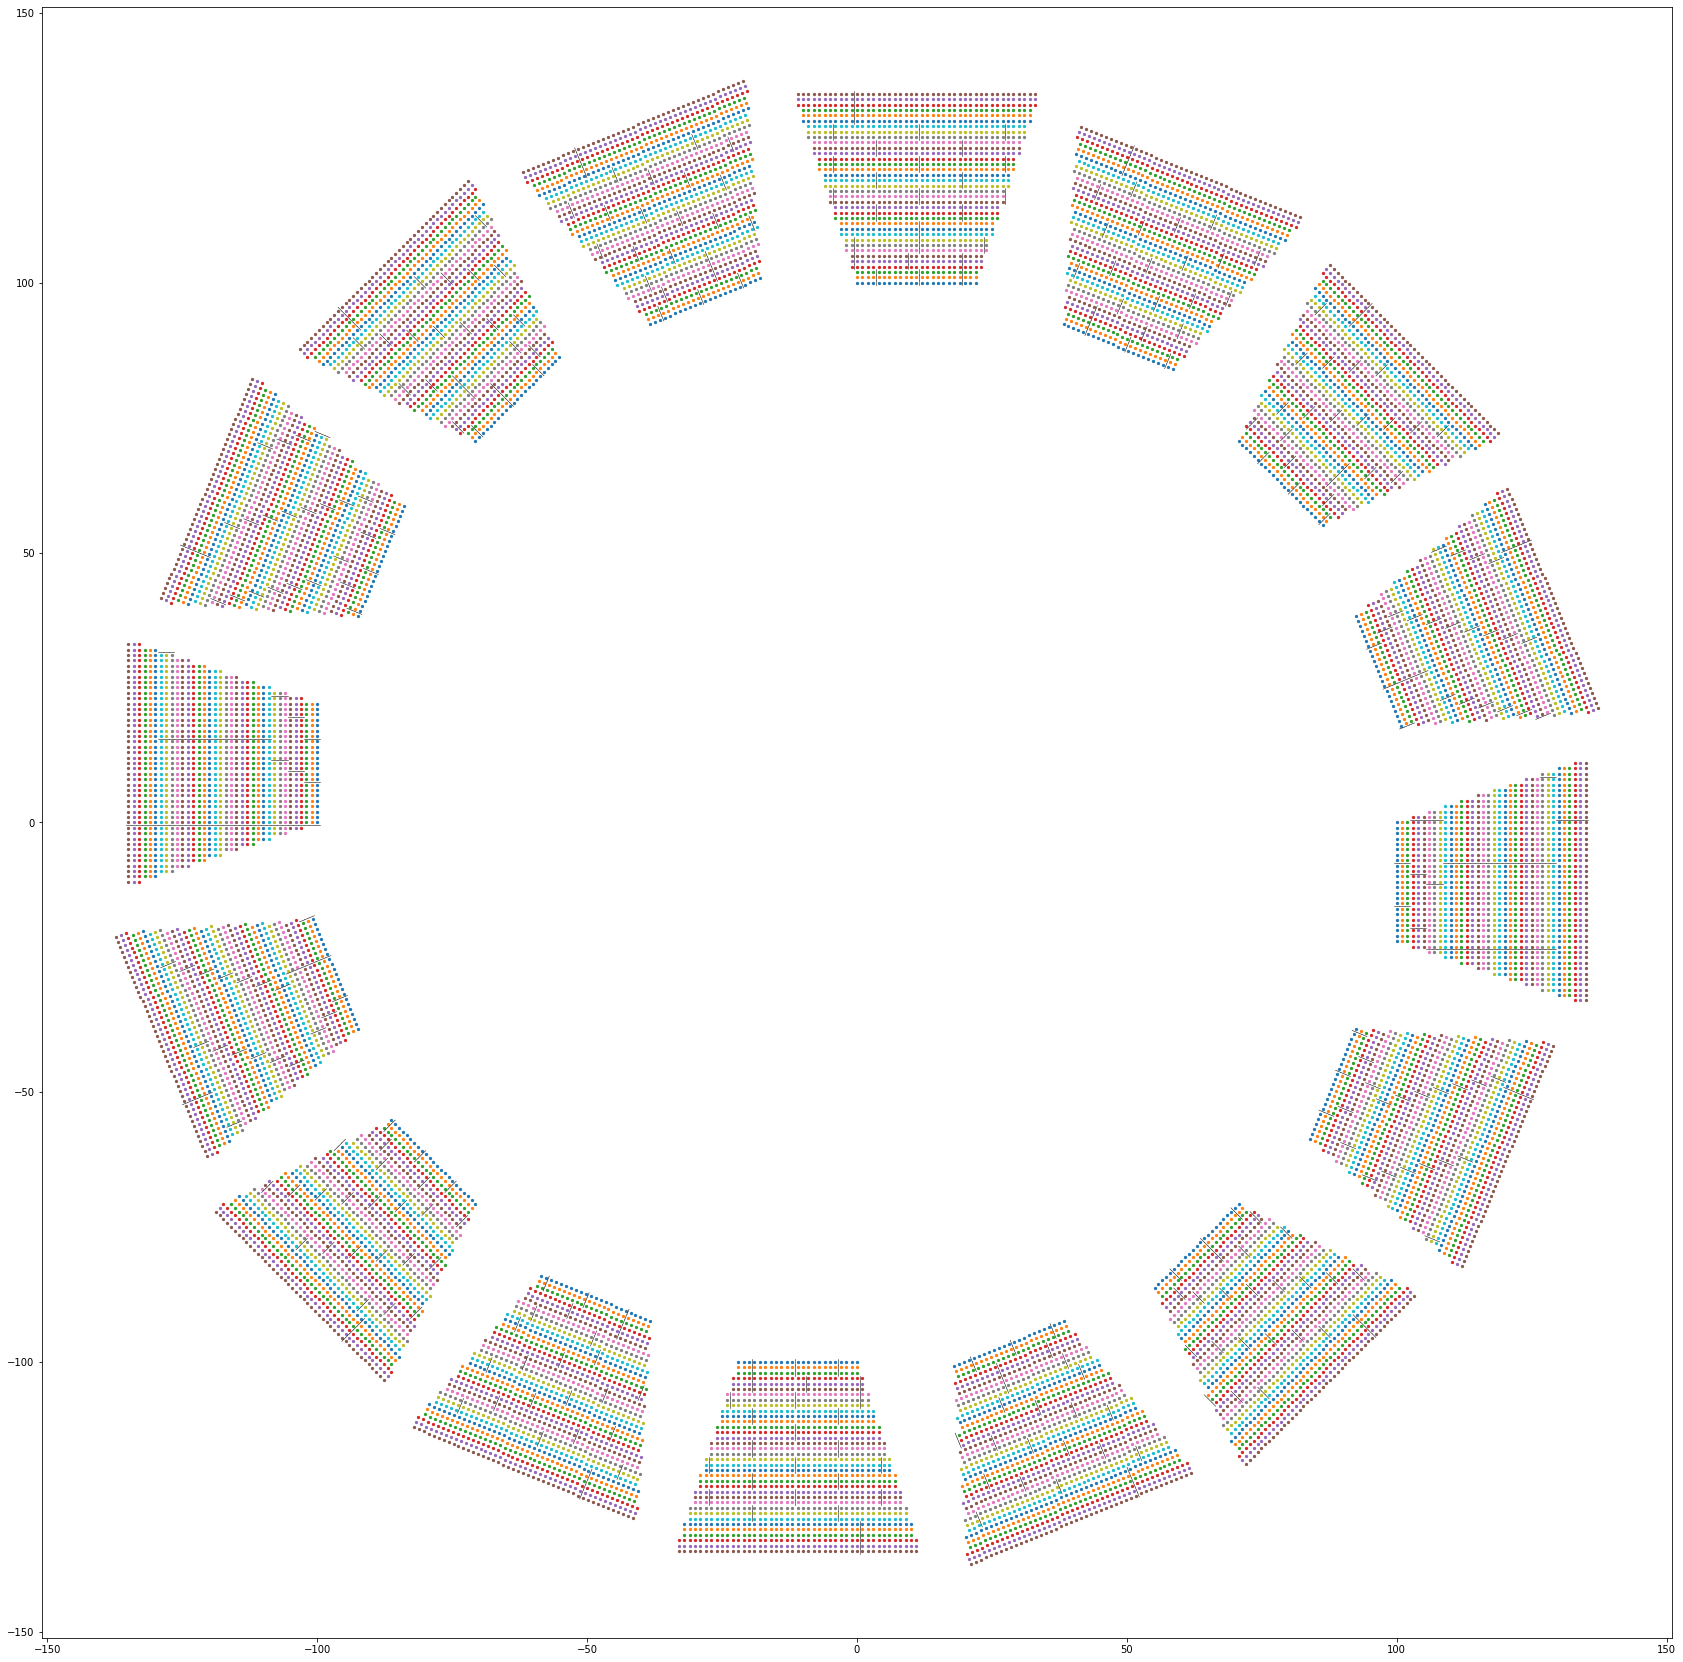

Cells per patch in phi: {0: 8, 1: 8, 2: 8, 3: 10, 4: 10, 5: 10, 6: 12, 7: 12, 8: 12, 9: 16, 10: 16, 11: 16, 12: 16, 13: 16, 14: 16, 15: 16, 16: 16, 17: 16, 18: 16, 19: 16, 20: 16, 21: 16, 22: 16, 23: 16, 24: 16, 25: 16, 26: 16, 27: 16, 28: 16, 29: 16, 30: 43, 31: 43, 32: 43, 33: 45, 34: 45, 35: 45}, cells per patch in z: 11
Layers 0-3: 23 cells / wedge, 46 2D boxes in r-phi, 966.0 patches in r-phi-z
Layers 3-6: 23 cells / wedge, 46 2D boxes in r-phi, 966.0 patches in r-phi-z
Layers 6-9: 23 cells / wedge, 46 2D boxes in r-phi, 966.0 patches in r-phi-z
Layers 9-12: 25 cells / wedge, 40 2D boxes in r-phi, 840.0 patches in r-phi-z
Layers 12-15: 25 cells / wedge, 40 2D boxes in r-phi, 840.0 patches in r-phi-z
Layers 15-18: 25 cells / wedge, 40 2D boxes in r-phi, 840.0 patches in r-phi-z
Layers 18-21: 27 cells / wedge, 36 2D boxes in r-phi, 756.0 patches in r-phi-z
Layers 21-24: 27 cells / wedge, 36 2D boxes in r-phi, 756.0 patches in r-phi-z
Layers 24-27: 27 cells / wedge, 36 2D boxes in r-

In [12]:

offsets = {}
for i in range(len(detector_patching_params["barrel_configs"]["cells_per_wedge"])):
    offsets[i] = int((detector_patching_params["barrel_configs"]["cells_per_wedge"][i] - detector_patching_params["barrel_configs"]["cells_per_wedge"][0]) / 2)

detector_patching_params["barrel_configs"]["offsets"] = offsets


R = 100 # 300
assert(int(detector_patching_params["barrel_configs"]["n_bins_z"]/detector_patching_params["barrel_configs"]["cells_per_patch_z"])==detector_patching_params["barrel_configs"]["n_bins_z"]/detector_patching_params["barrel_configs"]["cells_per_patch_z"])



patches_phi_per_ring, delta_phi_per_ring, delta_etas_per_ring = do_detector_patching(
    detector_patching_params,
    R,
)

In [13]:


# # ---------------------------------------------------------------------------
# # 4.  Convenience: flatten patches into a sequence of tokens
# # ---------------------------------------------------------------------------

# def patches_to_token_sequence(
#     patch_results: Dict[int, Dict],
#     registry: PatchRegistry,
#     flatten_cells: bool = True,
# ) -> Tuple[np.ndarray, np.ndarray, List[PatchInfo]]:
#     """
#     Convert the per-patch dict into the (tokens, pos_enc, patch_infos) triple
#     expected by a standard Transformer encoder.

#     Parameters
#     ----------
#     patch_results : output of assign_hits_to_patches
#     registry      : the PatchRegistry used during assignment
#     flatten_cells : if True, each token is a 1-D vector (cells unrolled);
#                     if False, each token is the raw 3-D tensor.

#     Returns
#     -------
#     tokens      : np.ndarray  (N_patches, n_cells)  if flatten_cells else list of arrays
#     pos_enc     : np.ndarray  (N_patches, embed_dim)
#     patch_infos : list of PatchInfo in the same order
#     """
#     ordered_ids = sorted(patch_results.keys())
#     patch_infos = [registry.patches[pid] for pid in ordered_ids]

#     pos_enc = np.stack([patch_results[pid]["pos_encoding"] for pid in ordered_ids])

#     if flatten_cells:
#         tokens = np.stack([
#             patch_results[pid]["cell_tensor"].ravel() for pid in ordered_ids
#         ])
#     else:
#         tokens = [patch_results[pid]["cell_tensor"] for pid in ordered_ids]

#     return tokens, pos_enc, patch_infos



In [14]:


registry, unique_patch_sizes, num_patches_total = build_patch_registry(detector_patching_params)

dd = 13


# Example: 36 cells for detector hits
x = np.array(data_dir["x"][data_dir["detector"] == dd])
y = np.array(data_dir["y"][data_dir["detector"] == dd])
z = np.array(data_dir["z"][data_dir["detector"] == dd])
energy = np.array(data_dir["total_energy"][data_dir["detector"] == dd])


results = assign_hits_to_patches_barrel(
    x,
    y,
    z,
    energy,
    registry,
    detector_patching_params,
) 




[Registry] 8379 patches
12 rings 
21 z-bins
phi patches/ring: 
   0: 46
   1: 40
   2: 36
   3: 29
   4: 31
   5: 33
   6: 35
   7: 37
   8: 39
   9: 41
   10: 16
   11: 16


In [22]:
print(results[0])

{'cell_tensor': array([[[0.        , 0.00055342, 0.00039454, 0.        , 0.        ,
         0.00188999, 0.00026615, 0.00236609, 0.        , 0.00389911,
         0.        ],
        [0.00291513, 0.00793344, 0.02293405, 0.04488985, 0.00741745,
         0.00710714, 0.00407247, 0.00831924, 0.00573038, 0.00155712,
         0.0105176 ],
        [0.00549624, 0.01041411, 0.01165763, 0.02450777, 0.00949597,
         0.00557805, 0.00688933, 0.01538231, 0.00083651, 0.01302779,
         0.01876715],
        [0.00113719, 0.00884014, 0.00932382, 0.01683123, 0.00372533,
         0.00113177, 0.00268244, 0.00159087, 0.01046754, 0.0159415 ,
         0.00375137],
        [0.00302567, 0.00894064, 0.02317144, 0.00631803, 0.00247367,
         0.00991721, 0.00425161, 0.02846074, 0.01125088, 0.04862409,
         0.00476533],
        [0.00435192, 0.01280111, 0.0087068 , 0.0117167 , 0.00632585,
         0.00906377, 0.00255934, 0.00333929, 0.03929066, 0.03244347,
         0.00350155],
        [0.00097977, 0.0

{'patch_id': 0, 'r_idx': 0, 'phi_idx': 0, 'z_idx': 0, 'r_center': 1698.5, 'phi_center': 0.06829549246934333, 'z_center': -3300.0, 'layer_start': 0, 'layer_stop': 2, 'phi_cell_start': 0, 'phi_cell_stop': 7, 'z_cell_start': 0, 'z_cell_stop': 10}


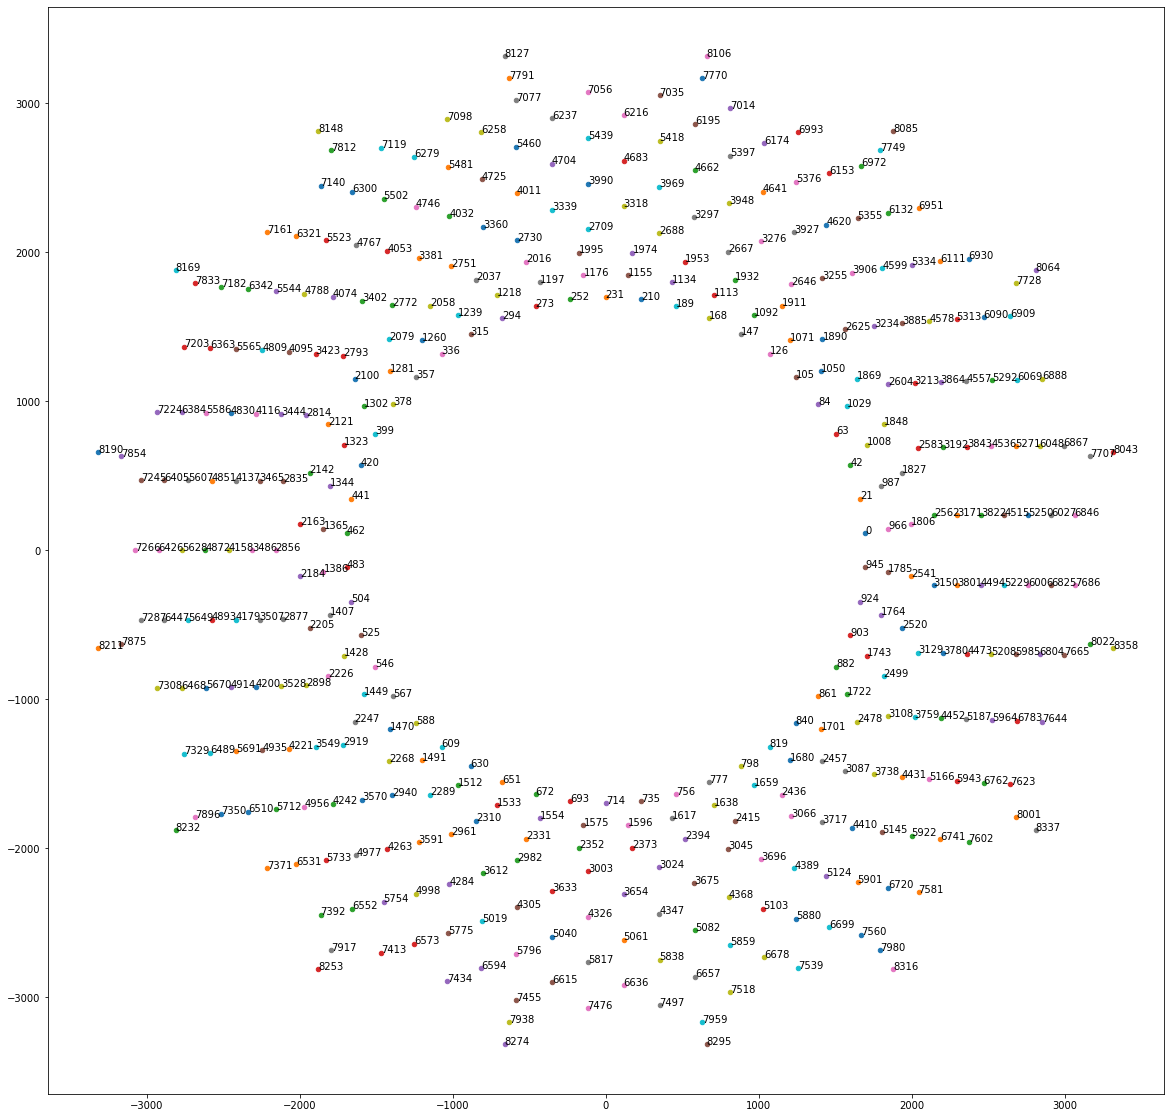

In [19]:
ordered_ids = sorted(results.keys())
patch_infos = [registry["patches"][pid] for pid in ordered_ids]
print(patch_infos[0])

plt.figure(figsize = (20, 20))
for i in range(len(ordered_ids)):
    if patch_infos[i]["z_center"] == (-3300):
        plt.scatter(patch_infos[i]["r_center"]*np.cos(patch_infos[i]["phi_center"]), patch_infos[i]["r_center"]*np.sin(patch_infos[i]["phi_center"]), s = 20)
        plt.text(patch_infos[i]["r_center"]*np.cos(patch_infos[i]["phi_center"]), patch_infos[i]["r_center"]*np.sin(patch_infos[i]["phi_center"]), patch_infos[i]["patch_id"])
plt.show()

In [ ]:
# this gives the number of unique embedding vectors we need


print(unique_patch_sizes)

In [ ]:
966+840+756+5145+336+336